In [2]:
import joblib
import pandas as pd
import shap

model = joblib.load("../models/diabetes_model.pkl")

df = pd.read_csv("../data/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(X.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [3]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print(X.shape)

(768, 8)


In [4]:
explainer = shap.Explainer(model, X)

In [5]:
shap_values = explainer.shap_values(
    X,
    check_additivity=False
)

 96%|=================== | 1468/1536 [00:16<00:00]       

In [6]:
print(type(shap_values))

<class 'numpy.ndarray'>


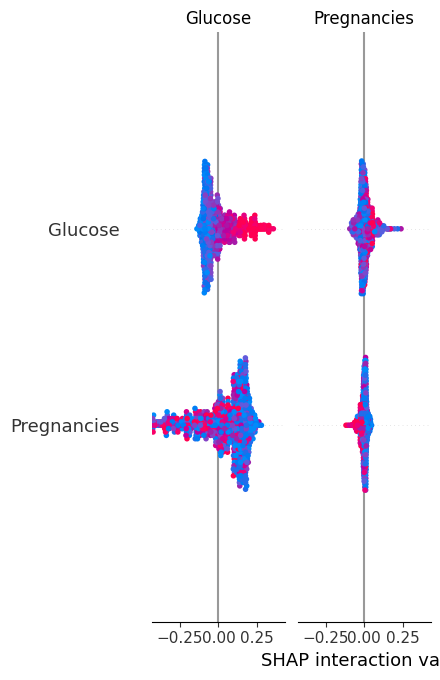

In [7]:
shap.summary_plot(
    shap_values,
    X
)

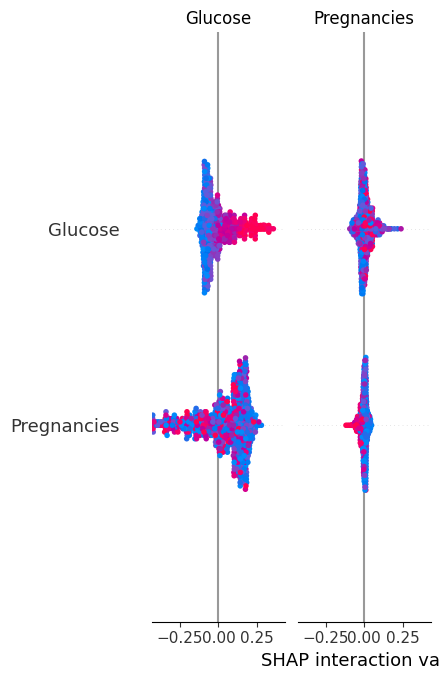

In [8]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [9]:
print(type(shap_values))

print(getattr(shap_values, "shape", "No Shape"))

<class 'numpy.ndarray'>
(768, 8, 2)


In [10]:
import shap

shap_explanation = shap.Explanation(
    values=shap_values[:, :, 1],          # Select positive class
    base_values=explainer.expected_value[1],
    data=X.values,
    feature_names=X.columns.tolist()
)

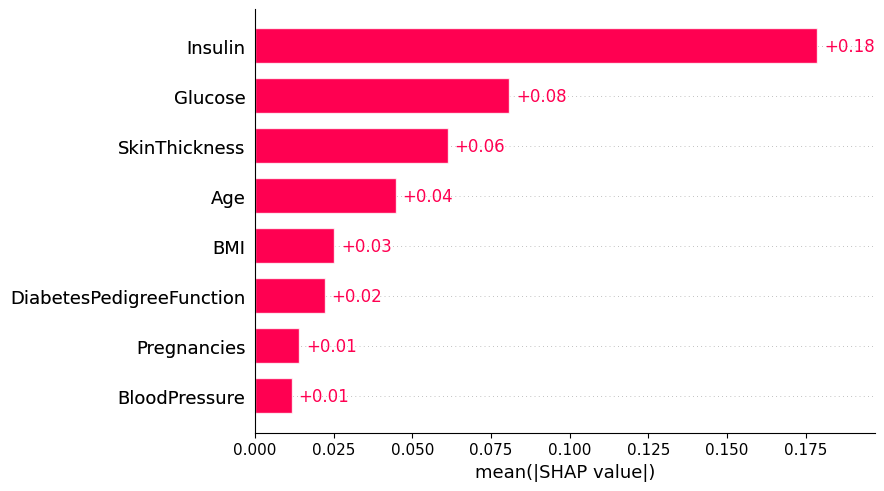

In [11]:
shap.plots.bar(shap_explanation)

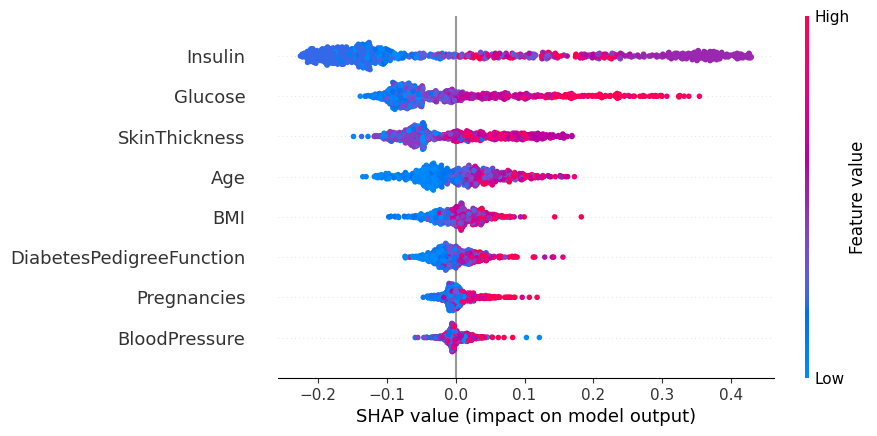

In [12]:
shap.plots.beeswarm(shap_explanation)

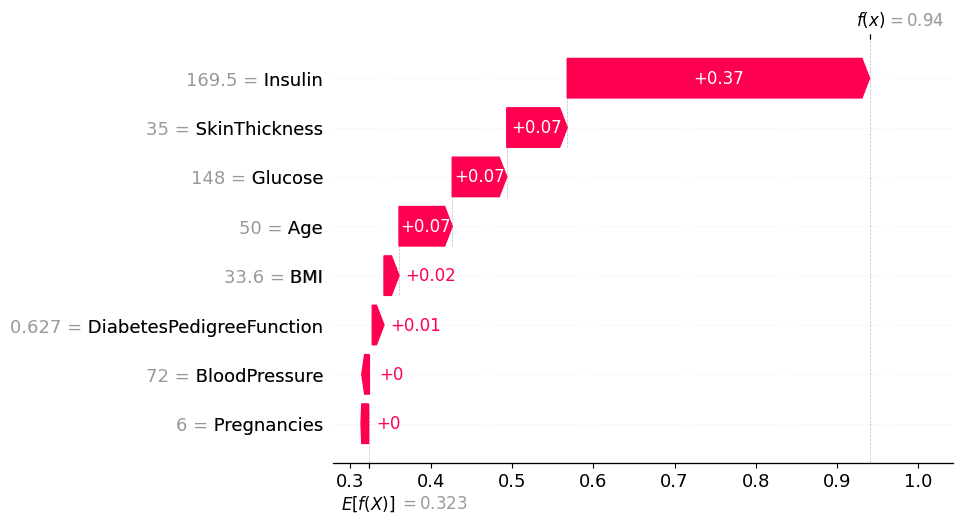

In [13]:
shap.plots.waterfall(shap_explanation[0])

In [14]:
shap.initjs()

shap.plots.force(shap_explanation[0])

In [15]:
import joblib

model = joblib.load("modules/diabetes/models/diabetes_model.pkl")

print(type(model))

FileNotFoundError: [Errno 2] No such file or directory: 'modules/diabetes/models/diabetes_model.pkl'